### Install pre-requistes


In [ ]:
!pip install --upgrade SPARQLWrapper pandas matplotlib --quiet

In [ ]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ENDPOINT_URL = "http://localhost:7200/repositories/KG-Questionnarie"

PREFIXES = """\
PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ds:   <http://digistrucmed.org/questionnaire#>
"""

In [ ]:
def run_query(query: str) -> pd.DataFrame:
    """Run a SPARQL SELECT query and return the results as a Pandas DataFrame."""
    sparql = SPARQLWrapper(ENDPOINT_URL)
    sparql.setReturnFormat(JSON)
    sparql.setQuery(PREFIXES + "\n" + query)
    results = sparql.query().convert()

    cols = results["head"].get("vars", [])
    rows = []
    for b in results["results"]["bindings"]:
        row = {}
        for c in cols:
            val = b.get(c, {}).get("value")
            row[c] = val
        rows.append(row)
    return pd.DataFrame(rows, columns=cols)

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_colwidth", 120)

## 1. Overview: all instances and their types

This query gives a quick overview of the entities in your graph and their Boxology types.


In [ ]:
q1 = """\
SELECT DISTINCT ?type
WHERE {
  ?entity rdf:type ?type .
}
"""
df1 = run_query(q1)
df1.head(50)

## 2. Distribution of instances per class

Counts how many instances there are of each Boxology class.

In [ ]:
q2 = """\
SELECT DISTINCT ?type (COUNT(?instance) AS ?count)
WHERE {
  ?instance rdf:type ?type .
}
GROUP BY ?type
ORDER BY DESC(?count)
"""

df2 = run_query(q2)
df2

In [ ]:

if not df2.empty:
    df2_plot = df2.copy()
    df2_plot["count"] = pd.to_numeric(df2_plot["count"], errors="coerce")
    df2_plot = df2_plot.dropna(subset=["count"])
    plt.figure(figsize=(12, 4))
    plt.xticks(rotation=60, ha="right")
    plt.title("Instances per Questionnaire class")
    plt.ylabel("Count")
    plt.xlabel("Class")
    plt.bar(df2_plot["type"], df2_plot["count"])
    plt.tight_layout()
else:
    print("No data to plot for query 2.")

## 3. List the number of answers are answered by users in each questionnarie.


In [ ]:
q3 = """\
SELECT DISTINCT ?user (COUNT(?instance) AS ?count) ?questionnarie
WHERE {
  ?instance rdf:type <http://digistrucmed.org/questionnaire#Answered>;
    <http://digistrucmed.org/questionnaire#answeredByUser> ?user;
    <http://digistrucmed.org/questionnaire#answeredInQuestionnaire> ?questionnarie.
}
GROUP BY ?user ?questionnarie
ORDER BY DESC(?count)
"""

df3 = run_query(q3)
df3

## 4.Network Degree Centrality of Questionnaire Entities
Using predicate edges.

In [ ]:
# Build a Questionnaire relations
q_edges = """
SELECT ?s ?p ?o
WHERE {
  ?s ?p ?o .
  FILTER(?p IN (
    ds:belongsTo,
    ds:hasPossibleAnswer,
    ds:isAnswerTo,
    ds:answeredByUser,
    ds:answeredOnPlatform,
    ds:answeredInQuestionnaire,
    ds:hasQuestion,
    ds:hasAnswer
  ))
  FILTER(isIRI(?s) && isIRI(?o))
}
"""

# Run query
df_edges = run_query(q_edges)

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

G = nx.Graph()
for _, r in df_edges.iterrows():
    G.add_edge(r['s'], r['o'])

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

# Degree centrality for all nodes
deg_centrality = nx.degree_centrality(G)

# Convert to DataFrame and show top 20 most central nodes
df_deg = (
    pd.DataFrame(deg_centrality.items(), columns=['node', 'centrality'])
      .sort_values('centrality', ascending=False)
)

display(df_deg.head(20))

# --- Average number of neighbors (average degree) ---
degrees = dict(G.degree())
if len(degrees) > 0:
    avg_neighbors = sum(degrees.values()) / len(degrees)
else:
    avg_neighbors = 0

print("Average number of neighbors (overall):", avg_neighbors)

# --- Restrict to pattern nodes only ---
pattern_nodes = set(df_edges['s'].unique())
pattern_degrees = [degrees[n] for n in pattern_nodes if n in degrees]
if pattern_degrees:
    avg_neighbors_patterns = sum(pattern_degrees) / len(pattern_degrees)
    print("Average number of neighbors (patterns only):", avg_neighbors_patterns)

# Data nodes as complement
data_nodes = set(df_edges['o'].unique()) - pattern_nodes
data_degrees = [degrees[n] for n in data_nodes if n in degrees]
if data_degrees:
    avg_neighbors_data = sum(data_degrees) / len(data_degrees)
    print("Average number of neighbors (data nodes only):", avg_neighbors_data)

# --- Additional global metrics ---
if G.number_of_nodes() > 0:
        # Average shortest path length on the largest connected component
    try:
        if nx.is_connected(G):
            asp = nx.average_shortest_path_length(G)
        else:
            largest_cc = max(nx.connected_components(G), key=len)
            H = G.subgraph(largest_cc).copy()
            asp = nx.average_shortest_path_length(H)
        print("Average shortest path length (largest component):", asp)
    except Exception as e:
        print("Could not compute average shortest path length:", e)

# --- Network Visualization ---
subG = G
if G.number_of_nodes() > 200:
    # take an induced subgraph on the 200 highest degree nodes to keep the plot readable
    top_nodes = [n for n, _ in sorted(G.degree, key=lambda x: x[1], reverse=True)[:200]]
    subG = G.subgraph(top_nodes).copy()

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(subG, seed=0)

nx.draw(subG, pos, with_labels=False, node_size=50)
plt.title("Questionnaire-Node Graph")
plt.show()

,question_short,questionText,responseCode,answer,frequency,percentage
0,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,10,sehr [10],61,22.93
1,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,8,[8],44,16.54
2,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,8,Skalenwert 8,44,16.54
3,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,9,[9],29,10.90
4,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,9,Skalenwert 9,29,10.90
...,...,...,...,...,...,...
95,SU01_01,"System Usability Scale (SUS): Ich denke, ich w�rde die Lernplattform gerne h�ufiger benutzen.",3,Likert response 3,20,37.74
96,SU01_01,"System Usability Scale (SUS): Ich denke, ich w�rde die Lernplattform gerne h�ufiger benutzen.",5,trifft voll zu,11,20.75
97,SU01_01,"System Usability Scale (SUS): Ich denke, ich w�rde die Lernplattform gerne h�ufiger benutzen.",4,Likert response 4,11,20.75
98,SU01_01,"System Usability Scale (SUS): Ich denke, ich w�rde die Lernplattform gerne h�ufiger benutzen.",NaN,No recorded response,8,15.09


,responseCode,answer,frequency,percentage
55,10,sehr gut [10],55,20.22
56,8,[8],46,16.91
57,8,Skalenwert 8,46,16.91
58,9,[9],34,12.50
59,9,Skalenwert 9,34,12.50
60,7,[7],12,4.41
61,7,Skalenwert 7,12,4.41
62,6,[6],8,2.94
63,6,Skalenwert 6,8,2.94
64,5,[5],4,1.47


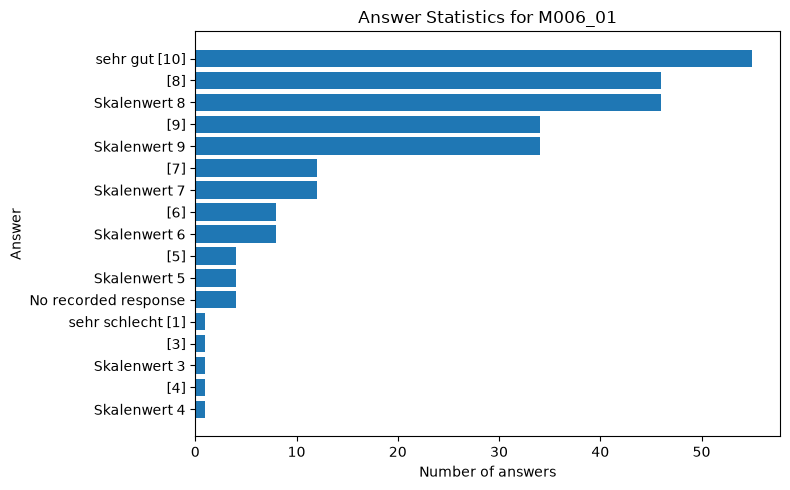

,responseCode,answer,frequency,percentage
108,NaN,No recorded response,543,14.70
103,8,Skalenwert 8,185,5.01
105,9,Skalenwert 9,185,5.01
104,8,[8],185,5.01
106,9,[9],185,5.01
107,TEXT,Textual response,160,4.33
72,4,Likert response 4,134,3.63
96,5,trifft gar nicht zu,114,3.09
18,10,sehr gut [10],114,3.09
55,4,4,112,3.03


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Helper
def short_uri(x):
    if pd.isna(x):
        return x
    x = str(x)
    return x.split("#")[-1] if "#" in x else x

# ------------------------------------------------------------
# Simple answer statistics per question
# ------------------------------------------------------------

q_answer_stats = """
SELECT
    ?question
    ?questionText
    ?responseCode
    ?responseLabel
    (COUNT(DISTINCT ?answered) AS ?frequency)
WHERE {
    ?answered ds:hasQuestion ?question ;
              ds:hasAnswer ?answer .

    OPTIONAL { ?question ds:QuestionDescription ?questionText . }
    OPTIONAL { ?answer ds:ResponseCode ?responseCode . }
    OPTIONAL { ?answer ds:ResponseLabel ?responseLabel . }
}
GROUP BY ?question ?questionText ?responseCode ?responseLabel
ORDER BY ?question DESC(?frequency)
"""

df = run_query(q_answer_stats)

df["frequency"] = df["frequency"].astype(int)
df["question_short"] = df["question"].apply(short_uri)

df["answer"] = df["responseLabel"].fillna(df["responseCode"])
df["total_per_question"] = df.groupby("question")["frequency"].transform("sum")

df["percentage"] = (
    df["frequency"] / df["total_per_question"] * 100
).round(2)

df = df.sort_values(
    ["question_short", "frequency"],
    ascending=[True, False]
)

display(df[[
    "question_short",
    "questionText",
    "responseCode",
    "answer",
    "frequency",
    "percentage"
]].head(100))

# For one specific question, show the distribution of answers
question_id = "M006_01"   # change this

one_question = df[df["question_short"] == question_id]

display(one_question[[
    "responseCode",
    "answer",
    "frequency",
    "percentage"
]])

plt.figure(figsize=(8, 5))
plt.barh(one_question["answer"], one_question["frequency"])
plt.gca().invert_yaxis()
plt.xlabel("Number of answers")
plt.ylabel("Answer")
plt.title(f"Answer Statistics for {question_id}")
plt.tight_layout()
plt.show()

#For an overall view, show the most common answers across all questions
overall = (
    df.groupby(["responseCode", "answer"], dropna=False)["frequency"]
    .sum()
    .reset_index()
    .sort_values("frequency", ascending=False)
)

overall["percentage"] = (
    overall["frequency"] / overall["frequency"].sum() * 100
).round(2)

display(overall.head(30))